In [1]:
import numpy as np
import lhapdf
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as ticker

lhapdf.setVerbosity(0)

mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.weight": "bold"
})
mpl.rcParams['text.latex.preamble'] = r'''
\usepackage{amsmath}
\usepackage{xcolor}
'''

In [2]:
def Rcpm(x, PDF_fit, mu_fact, valence_s_flag):
    epsilon = 0.222**2 / 0.975**2
    xdm = PDF_fit.xfxQ(1, x, mu_fact) - PDF_fit.xfxQ(-1, x, mu_fact)
    xsp = PDF_fit.xfxQ(3, x, mu_fact) + PDF_fit.xfxQ(-3, x, mu_fact)
    xsm = PDF_fit.xfxQ(3, x, mu_fact) - PDF_fit.xfxQ(-3, x, mu_fact)
    if (valence_s_flag == 'on'):
        return 1. - (epsilon * xdm + xsm) / xsp
    else:
        return 1. - epsilon * xdm / xsp

In [18]:
font_size = 21
legend_font_size = 19
axis_label_font_size = 25
axis_font_size = 19

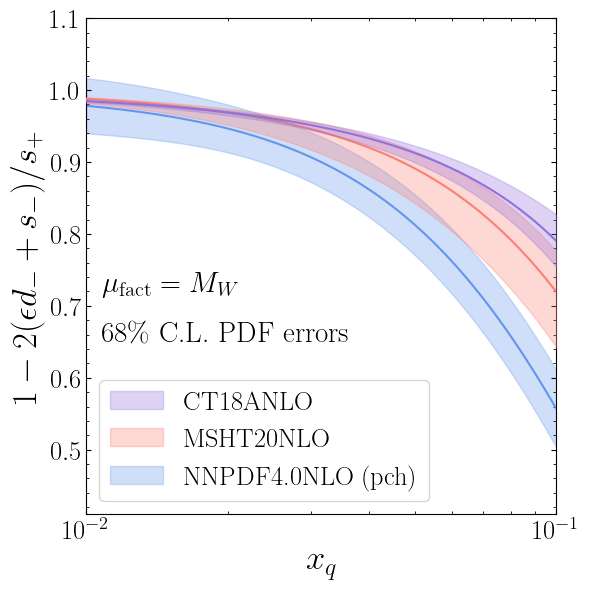

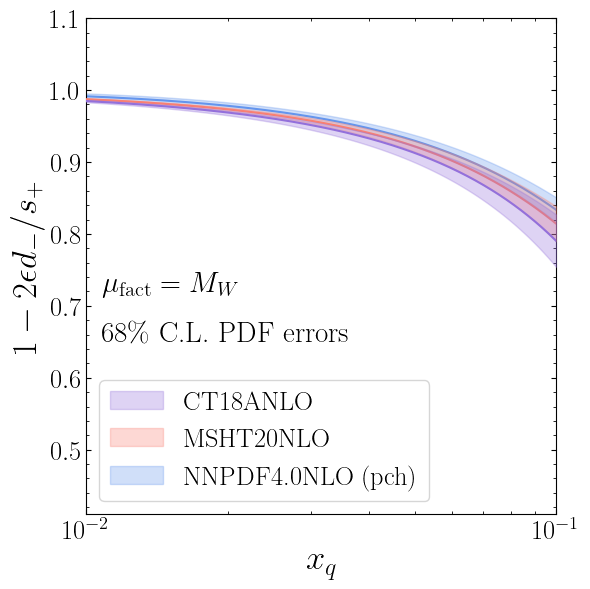

In [20]:
import numpy as np
import lhapdf
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as ticker

lhapdf.setVerbosity(0)

mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.weight": "bold"
})
mpl.rcParams['text.latex.preamble'] = r'''
\usepackage{amsmath}
\usepackage{xcolor}
'''

def Rcpm(x, PDF_fit, mu_fact, valence_s_flag):
    epsilon = 0.22438**2 / 0.97359**2
    xdv = PDF_fit.xfxQ(1, x, mu_fact) - PDF_fit.xfxQ(-1, x, mu_fact)
    xs = PDF_fit.xfxQ(3, x, mu_fact)
    xsv = xs - PDF_fit.xfxQ(-3, x, mu_fact)
    if (valence_s_flag == 'on'):
        return 1. - (epsilon * xdv + xsv) / xs
    else:
        return 1. - epsilon * xdv / xs

valence_s_flags = ['on', 'off']
PDF_fits = ['CT18ANLO', 'MSHT20nlo_as118', 'NNPDF40_nlo_pch_as_01180']
PDF_labels = ['CT18ANLO', 'MSHT20NLO', 'NNPDF4.0NLO (pch)']
num_err_members = [58, 64, 100]
fitting_methods = ['Hessian', 'Hessian', 'MC']
colors = ['mediumpurple', 'salmon', 'cornflowerblue']
zorders = [3, 2, 1]
N = 1000
X = np.linspace(1e-2, 1e-1, N)
mu_fact = 80.385

for valence_s_flag in valence_s_flags:
    fig, ax = plt.subplots(figsize=(6, 6))

    for PDF_fit_index in range(len(PDF_fits)):
        PDF_fit = PDF_fits[PDF_fit_index]
        PDF = lhapdf.mkPDF(PDF_fit, 0)
        vals = np.zeros(N)
        errs_up = np.zeros(N)
        errs_down = np.zeros(N)

        member_PDFs = [lhapdf.mkPDF(PDF_fit, member) for member in range(num_err_members[PDF_fit_index] + 1)]

        for i in range(N):
            member_vals = np.zeros(num_err_members[PDF_fit_index] + 1)

            for member in range(num_err_members[PDF_fit_index] + 1):
                member_vals[member] = Rcpm(X[i], member_PDFs[member], mu_fact, valence_s_flag)

            err_plus = 0.
            err_minus = 0.

            if (fitting_methods[PDF_fit_index] == "Hessian"):
                for j in range(1, int(num_err_members[PDF_fit_index] / 2) + 1):
                    plus_member = 2 * j - 1
                    minus_member = 2 * j

                    err_plus += max(max(member_vals[plus_member] - member_vals[0], member_vals[minus_member] - member_vals[0]), 0.)**2
                    err_minus += max(max(member_vals[0] - member_vals[plus_member], member_vals[0] - member_vals[minus_member]), 0.)**2
                
                errs_up[i] = np.sqrt(err_plus)
                errs_down[i] = np.sqrt(err_minus)

                vals[i] = member_vals[0]

            elif (fitting_methods[PDF_fit_index] == "MC"):
                errs_up[i] = np.sqrt(1. / (num_err_members[PDF_fit_index] * 1. - 1.) * sum((member_vals[1:] - member_vals[0])**2))
                errs_down[i] = errs_up[i]

                vals[i] = sum(member_vals[1:]) / (num_err_members[PDF_fit_index] * 1.)

            else:
                print("ERROR: INVALID FITTING METHOD")
                exit(1)
            
        if (PDF_fit == 'CT18ANLO'):
            errs_up = errs_up  / 1.645
            errs_down = errs_down / 1.645
        
        ax.plot(X, vals, zorder=zorders[PDF_fit_index] * 2, color=colors[PDF_fit_index])
        ax.fill_between(X, vals + errs_up, vals - errs_down, alpha=0.3, zorder=zorders[PDF_fit_index] * 2 - 1,
                        color=colors[PDF_fit_index], label=PDF_labels[PDF_fit_index])

    ax.set_xlim(1e-2, 1e-1)
    ax.set_xscale('log')
    ax.xaxis.set_major_locator(ticker.FixedLocator([1e-2, 1e-1]))
    ax.xaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(2, 10)*0.1))
    ax.xaxis.set_minor_formatter(ticker.NullFormatter())

    ax.minorticks_on()
    ax.tick_params(which='both', direction='in', top=True, right=True, zorder=100, labelsize=axis_font_size)

    ax.set_xlabel(r'$x_q$', fontsize=axis_label_font_size)
    if (valence_s_flag == 'on'):
        ax.set_ylabel(r'$1 - 2(\epsilon d_- + s_-) / s_+$', fontsize=axis_label_font_size)
    else:
        ax.set_ylabel(r'$1 - 2\epsilon d_- / s_+$', fontsize=axis_label_font_size)
    
    ax.set_ylim(0.41, 1.1)
    plt.text(1e-2 * 1.08, 0.72, r'$\mu_\text{fact} = M_W$', fontsize=font_size)
    plt.text(1e-2 * 1.08, 0.65, r'$68\% \text{ C.L. PDF errors}$', fontsize=font_size)
    plt.legend(loc='lower left', fontsize=legend_font_size)
    plt.tight_layout()
    plt.savefig('Rcpm_from_PDFs_valence_s_' + valence_s_flag + '.pdf')
    plt.show()
